# 📊 Proyecto de Ciencia de Datos

## Análisis Exploratorio de Datos (EDA)

Este proyecto tiene como objetivo aplicar técnicas de análisis estadístico, limpieza de datos y visualización utilizando Python.

## 1. Contexto del problema

Se cuenta con un conjunto de datos con variables numéricas y una variable objetivo (`target`). El objetivo es analizar la calidad de los datos y su comportamiento estadístico.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Entorno listo para análisis de datos.")

Entorno listo para análisis de datos.


## 2. Carga de datos
Se cargaron dos conjuntos de datos: entrenamiento y prueba.

- Dataset 1: df1
- Dataset 2: df2 (incluye variable objetivo `target`)

In [3]:
df1 = pd.read_csv("../data/raw/test.csv")
df2 = pd.read_csv("../data/raw/train.csv")

print(df1.head())
print(df2.head())

   Id     1     2   3   4   5   6   7
0   1  6.80  5.40 NaN NaN NaN NaN NaN
1   2  4.71  4.20 NaN NaN NaN NaN NaN
2  32  2.10  3.40 NaN NaN NaN NaN NaN
3  40  5.35  5.85 NaN NaN NaN NaN NaN
4  43  4.80  5.30 NaN NaN NaN NaN NaN
   Id  target     1     2   3   4   5   6   7
0   0    5.85  4.80  5.85 NaN NaN NaN NaN NaN
1   3    4.28  5.88  6.84 NaN NaN NaN NaN NaN
2   4    3.97  3.20  2.70 NaN NaN NaN NaN NaN
3   5    5.95  7.70  7.06 NaN NaN NaN NaN NaN
4   6    4.70  5.50  5.30 NaN NaN NaN NaN NaN


## 3. Exploración inicial

Se revisa la estructura de los datos, tipos de variables y valores nulos.

In [4]:
df1.info()
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      63 non-null     int64  
 1   1       63 non-null     float64
 2   2       63 non-null     float64
 3   3       15 non-null     float64
 4   4       15 non-null     float64
 5   5       16 non-null     float64
 6   6       14 non-null     float64
 7   7       14 non-null     float64
dtypes: float64(7), int64(1)
memory usage: 4.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      147 non-null    int64  
 1   target  147 non-null    float64
 2   1       145 non-null    float64
 3   2       145 non-null    float64
 4   3       32 non-null     float64
 5   4       31 non-null     float64
 6   5       33 non-null     float64
 7   6       37 non-null     float64
 8   7       37 non-null  

## 4. Calidad de los datos

Se analiza la presencia de valores nulos y su impacto en el análisis.

In [5]:
# Ver porcentaje de datos faltantes
print(df1.isnull().mean() * 100)
print(df2.isnull().mean() * 100)

Id     0.000000
1      0.000000
2      0.000000
3     76.190476
4     76.190476
5     74.603175
6     77.777778
7     77.777778
dtype: float64
Id         0.000000
target     0.000000
1          1.360544
2          1.360544
3         78.231293
4         78.911565
5         77.551020
6         74.829932
7         74.829932
dtype: float64


## 5. Limpieza de datos

Se eliminan variables con alto porcentaje de valores faltantes para mejorar la calidad del análisis.

In [6]:
threshold = 0.7

df1_clean = df1.loc[:, df1.isnull().mean() < threshold]
df2_clean = df2.loc[:, df2.isnull().mean() < threshold]

df1_clean.shape, df2_clean.shape

((63, 3), (147, 4))

## 6. Variable objetivo

La variable objetivo del análisis es `target`, la cual será utilizada para estudiar relaciones con las variables predictoras.

In [7]:
X = df2.drop(columns=["target"])
y = df2["target"]

print(X.shape)
print(y.shape)

(147, 8)
(147,)


## 7. Análisis exploratorio (EDA)

Se realiza análisis estadístico descriptivo y visualización de los datos.

In [8]:
df2_clean.describe()

,Id,target,1,2
count,147.000000,147.000000,145.000000,145.000000
mean,101.401361,5.021633,4.972621,4.906552
std,64.836640,2.122535,2.044076,2.001357
min,0.000000,1.300000,0.900000,1.040000
25%,41.500000,3.720000,3.500000,3.400000
50%,102.000000,4.600000,4.800000,4.830000
75%,158.500000,6.275000,6.450000,6.200000
max,214.000000,11.700000,10.900000,11.000000


## 8. Correlación entre variables

Se analiza la relación entre variables numéricas para identificar patrones relevantes.

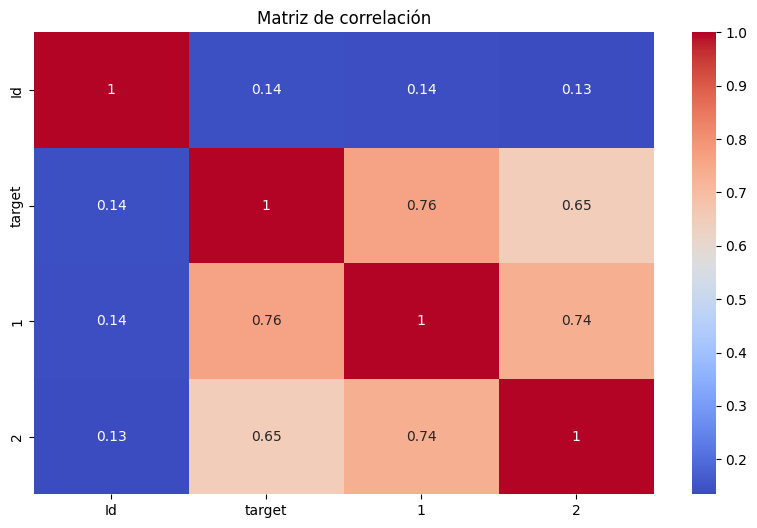

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df2_clean.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

## 9. Interpretación de correlaciones

A partir de la matriz de correlación se identifican las variables que tienen mayor relación con la variable objetivo (`target`). Esto permite entender qué variables aportan más información en el análisis.

In [10]:
corr = df2_clean.corr(numeric_only=True)

corr["target"].sort_values(ascending=False)

target    1.000000
1         0.762797
2         0.645750
Id        0.142551
Name: target, dtype: float64

## 10. Conclusión de variables

Se identifican las variables con mayor impacto sobre el target, lo cual es clave para futuras etapas de modelado o análisis predictivo.

## 11. Conceptos base: Población vs Muestra

En este análisis trabajamos con una muestra de datos, por lo que las métricas estadísticas utilizadas corresponden a estimadores muestrales como media, desviación estándar, cuartiles y rango intercuartílico.

In [11]:
df2_clean.describe()

,Id,target,1,2
count,147.000000,147.000000,145.000000,145.000000
mean,101.401361,5.021633,4.972621,4.906552
std,64.836640,2.122535,2.044076,2.001357
min,0.000000,1.300000,0.900000,1.040000
25%,41.500000,3.720000,3.500000,3.400000
50%,102.000000,4.600000,4.800000,4.830000
75%,158.500000,6.275000,6.450000,6.200000
max,214.000000,11.700000,10.900000,11.000000


## 12. Análisis univariado - variables numéricas

Se analizan medidas como media, mediana, desviación estándar, cuartiles, mínimo y máximo.

### 📊 GRÁFICA (histograma)

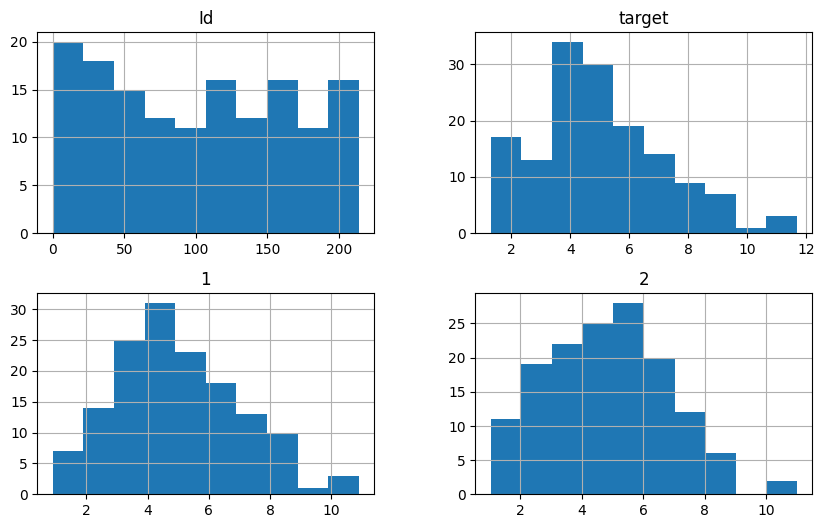

In [12]:
import matplotlib.pyplot as plt

df2_clean.hist(figsize=(10,6))
plt.show()

### 📊 BOXPLOT (outliers)

In [13]:
import plotly.express as px

# Genera un boxplot interactivo para todas las columnas numéricas de df2_clean
fig = px.box(df2_clean, title="Boxplots Interactivos de todas las variables")

fig.show()

### 📊 VARIABLES CATEGÓRICAS (si existen)

In [14]:
df2_clean.nunique()

Id        147
target     97
1         100
2          96
dtype: int64

### 📊 ANÁLISIS BIVARIADO

In [22]:
import plotly.express as px
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact

# 1. Calculamos la matriz de correlación base solo con datos numéricos
matriz_corr = df2_clean.corr(numeric_only=True)

# 2. Creamos el filtro interactivo (slider)
@interact(umbral=widgets.FloatSlider(
    value=0.0, 
    min=0.0, 
    max=0.9, 
    step=0.1, 
    description='Filtro |r| >:'
))
def mapa_correlacion_interactivo(umbral):
    
    # Hacemos una copia para filtrar sin dañar los datos originales
    matriz_filtrada = matriz_corr.copy()
    
    # Ocultamos las correlaciones que sean más débiles que el umbral elegido
    matriz_filtrada[(abs(matriz_filtrada) < umbral) & (matriz_filtrada != 1.0)] = np.nan
    
    # Generamos el mapa de calor interactivo
    fig = px.imshow(matriz_filtrada, 
                    text_auto=".2f", # Muestra los números con 2 decimales (como annot=True)
                    color_continuous_scale="RdBu_r", # Escala de colores equivalente a 'coolwarm'
                    zmin=-1, zmax=1, # Fija la escala para que los colores no salten al filtrar
                    aspect="auto",
                    title=f"Mapa de Calor de Correlaciones (Umbral > {umbral})")
    
    # Aplicamos el fondo transparente para la estética del proyecto
    fig.update_layout(
        paper_bgcolor='rgba(0,0,0,0)', 
        plot_bgcolor='rgba(0,0,0,0)'
    )
    
    fig.show()

interactive(children=(FloatSlider(value=0.0, description='Filtro |r| >:', max=0.9), Output()), _dom_classes=('…

## 13. Análisis bivariado

Se estudia la relación entre variables numéricas mediante correlación de Pearson.

In [21]:
import plotly.express as px
import ipywidgets as widgets
from ipywidgets import interact

# Obtenemos solo las columnas numéricas y excluimos el 'target'
columnas_x = [col for col in df2_clean.select_dtypes(include='number').columns if col != "target"]

# Creamos el menú desplegable interactivo
@interact(columna=widgets.Dropdown(
    options=columnas_x,
    value=columnas_x[0], # Muestra la primera por defecto
    description='Variable X:'
))
def scatter_interactivo_filtrado(columna):
    
    # Generamos el gráfico de dispersión
    fig = px.scatter(df2_clean, 
                     x=columna, 
                     y="target", 
                     title=f"Relación: {columna} vs target",
                     opacity=0.7,
                     trendline="ols", 
                     color="target", # <--- Aquí asignamos el color al valor del target
                     color_continuous_scale="Viridis") # <--- Escala de colores (puedes usar 'Blues', 'Reds', 'Plasma')
    
    # Aplicamos el fondo transparente
    fig.update_layout(
        paper_bgcolor='rgba(0,0,0,0)', 
        plot_bgcolor='rgba(0,0,0,0)'
    )
    
    fig.show()

interactive(children=(Dropdown(description='Variable X:', options=('Id', '1', '2'), value='Id'), Output()), _d…

## 14. Pruebas de hipótesis

Se evalúa si existen diferencias significativas entre variables mediante pruebas estadísticas con nivel de significancia de 0.05.

In [17]:
from scipy import stats

stats.ttest_ind(df2_clean.dropna().iloc[:,0], df2_clean.dropna().iloc[:,1])

TtestResult(statistic=np.float64(17.73776343642485), pvalue=np.float64(5.3968561560794056e-48), df=np.float64(286.0))

## 15. Conclusiones finales

A partir del análisis exploratorio realizado se concluye que:

- El dataset presenta un alto porcentaje de valores faltantes en algunas variables.
- Se identifican variables con mayor relación con la variable objetivo `target`.
- Las variables numéricas presentan diferentes niveles de dispersión y comportamiento estadístico.
- El análisis permite entender la estructura del fenómeno estudiado y sentar bases para un posible modelo predictivo.

Este análisis corresponde a un proceso de limpieza, exploración y entendimiento de datos (EDA).